# 09 Transformer Loss Function Experiments

This notebook keeps the transformer **architecture, feature set, and data split fixed** and changes only the training loss.

That makes the comparison much cleaner: if performance changes, we can attribute it mainly to the loss function rather than to another feature or architecture tweak.

The losses compared here are:

1. `mse_logvol`: the current baseline on `log_fvol_5d`,
2. `qlike`: a volatility-specific loss based on predicted variance,
3. `huber_logvol`: a more robust version of the log-vol error,
4. `weighted_huber`: Huber plus extra weight on volatility regime changes,
5. `weighted_qlike`: QLIKE plus extra weight on volatility regime changes.

We also report richer evaluation metrics than plain MSE: `RMSE`, `MAE`, `QLIKE`, `correlation`, and a simple `lag_days` diagnostic.

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Fixed transformer setup

To isolate the loss function, this notebook freezes the current transformer setup at the stronger regularized replacement version.

That means:

- feature set: the `replacement_hybrid` list from the previous notebook,
- architecture: 2-layer transformer encoder with `d_model=64`,
- lookback: `60` days,
- optimizer: `AdamW`,
- split: train through `2023`, validation `2024`, test `2025`.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

feature_list = [
    'high_low_log_range', 'log_volume',
    'realized_vol_21d', 'realized_vol_63d', 'hist_vol_21d', 'hist_vol_63d',
    'volume_zscore_5d', 'volume_zscore_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d', 'mkt_SPY_proxy_range',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d', 'mkt_QQQ_proxy_range',
    'mkt_QQQ_proxy_level_zscore_21d',
    'mkt_IWM_proxy_return', 'mkt_IWM_proxy_range', 'mkt_IWM_proxy_level_zscore_63d',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^VIX_proxy_level_zscore_63d',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
    'macro_^TNX_proxy_return', 'macro_^TNX_proxy_range',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'abs_return_mean_21d', 'realized_vol_10d',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

model_config = {
    'lookback': 60,
    'd_model': 64,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 128,
    'dropout': 0.3,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 30,
    'patience': 6,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

loss_specs = [
    {'name': 'mse_logvol', 'loss_name': 'mse'},
    {'name': 'qlike', 'loss_name': 'qlike'},
    {'name': 'huber_logvol', 'loss_name': 'huber', 'delta': 0.10},
    {'name': 'weighted_huber', 'loss_name': 'weighted_huber', 'delta': 0.10, 'weight_strength': 1.5},
    {'name': 'weighted_qlike', 'loss_name': 'weighted_qlike', 'weight_strength': 1.5},
]

display(pd.DataFrame({'feature_count': [len(feature_list)]}))
pd.DataFrame(loss_specs)

,feature_count
0,31


,name,loss_name,delta,weight_strength
0,mse_logvol,mse,NaN,NaN
1,qlike,qlike,NaN,NaN
2,huber_logvol,huber,0.1,NaN
3,weighted_huber,weighted_huber,0.1,1.5
4,weighted_qlike,weighted_qlike,NaN,1.5


## Data utilities and loss definitions

Two implementation details matter here:

- `QLIKE` is computed from **predicted variance**, so the model output is still interpreted as `log volatility`,
- the weighted losses use a simple regime-change weight based on the recent absolute change in the target log-volatility.

A positive `lag_days` in the final table means the prediction curve lines up slightly better after shifting it forward by that many days, which is a compact way to quantify the lag you noticed in the plots.

In [3]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'change_mag': torch.tensor(panel['change_mag'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def prepare_data(feature_list, lookback, batch_size):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std

    raw_change = experiment_df.groupby('Ticker', sort=False)['log_fvol_5d'].diff().abs().fillna(0.0)
    change_scale = float(raw_change[train_mask].quantile(0.90))
    change_scale = max(change_scale, 1e-6)
    experiment_df['change_mag'] = np.clip(raw_change / change_scale, 0.0, 2.0)

    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
            'change_mag': group['change_mag'].to_numpy(dtype=np.float32),
        }
    train_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=range(2016, train_end_year + 1))
    val_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[validation_year])
    test_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[test_year])
    return {
        'ticker_levels': ticker_levels,
        'train_loader': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'test_samples': len(test_dataset),
    }

def qlike_loss_from_logvol(pred_log, y_vol):
    pred_log_clipped = torch.clamp(pred_log, min=-6.0, max=6.0)
    pred_var = torch.exp(2.0 * pred_log_clipped)
    true_var = torch.clamp(y_vol ** 2, min=1e-8)
    return torch.log(pred_var) + true_var / pred_var

def compute_loss(loss_spec, pred_log, y_log, y_vol, change_mag):
    loss_name = loss_spec['loss_name']
    if loss_name == 'mse':
        base_loss = (pred_log - y_log) ** 2
    elif loss_name == 'huber':
        base_loss = F.huber_loss(pred_log, y_log, reduction='none', delta=loss_spec.get('delta', 0.1))
    elif loss_name == 'qlike':
        base_loss = qlike_loss_from_logvol(pred_log, y_vol)
    elif loss_name == 'weighted_huber':
        base_loss = F.huber_loss(pred_log, y_log, reduction='none', delta=loss_spec.get('delta', 0.1))
        weights = 1.0 + loss_spec.get('weight_strength', 1.5) * change_mag
        base_loss = base_loss * weights
    elif loss_name == 'weighted_qlike':
        base_loss = qlike_loss_from_logvol(pred_log, y_vol)
        weights = 1.0 + loss_spec.get('weight_strength', 1.5) * change_mag
        base_loss = base_loss * weights
    else:
        raise ValueError(f'Unknown loss: {loss_name}')
    return base_loss.mean()

def run_epoch(model, dataloader, loss_spec, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        y_vol = batch['y_vol'].to(DEVICE)
        change_mag = batch['change_mag'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = compute_loss(loss_spec, pred, y_log, y_vol, change_mag)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
            })
    return pd.DataFrame(rows)

def core_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
    }

def lag_profile(actual, prediction, max_lag=5):
    profile = {}
    actual = np.asarray(actual, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    for lag in range(max_lag + 1):
        if lag == 0:
            a = actual
            p = prediction
        else:
            a = actual[:-lag]
            p = prediction[lag:]
        if len(a) < 5 or np.std(a) == 0 or np.std(p) == 0:
            profile[lag] = np.nan
        else:
            profile[lag] = float(np.corrcoef(a, p)[0, 1])
    return profile

def lag_metrics(prediction_df, max_lag=5):
    lag_rows = []
    for _, group in prediction_df.sort_values(['Ticker', 'Date']).groupby('Ticker'):
        profile = lag_profile(group['fvol_5d'], group['prediction'], max_lag=max_lag)
        for lag, corr in profile.items():
            lag_rows.append({'Ticker': group['Ticker'].iloc[0], 'lag': lag, 'corr': corr})
    lag_df = pd.DataFrame(lag_rows)
    avg_profile = lag_df.groupby('lag', as_index=False)['corr'].mean()
    best_row = avg_profile.sort_values(['corr', 'lag'], ascending=[False, True]).iloc[0]
    return {
        'lag_days': int(best_row['lag']),
        'lag_best_corr': float(best_row['corr']),
        'lag0_corr': float(avg_profile.loc[avg_profile['lag'] == 0, 'corr'].iloc[0]),
    }, avg_profile

def evaluate_predictions(prediction_df):
    summary = core_metrics(prediction_df['fvol_5d'], prediction_df['prediction'])
    lag_summary, lag_curve = lag_metrics(prediction_df)
    summary.update(lag_summary)
    return summary, lag_curve

def train_experiment(loss_spec):
    data = prepare_data(feature_list, lookback=model_config['lookback'], batch_size=model_config['batch_size'])
    model = VolatilityTransformer(
        input_dim=len(feature_list),
        num_tickers=len(data['ticker_levels']),
        d_model=model_config['d_model'],
        nhead=model_config['nhead'],
        num_layers=model_config['num_layers'],
        dim_feedforward=model_config['dim_feedforward'],
        dropout=model_config['dropout'],
        ticker_embedding_dim=model_config['ticker_embedding_dim'],
        max_len=model_config['lookback'],
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=model_config['learning_rate'], weight_decay=model_config['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, model_config['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], loss_spec, optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], loss_spec, optimizer=None)
        history_rows.append({'experiment': loss_spec['name'], 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        print(f"{loss_spec['name']} | epoch {epoch}/{model_config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if epochs_without_improvement >= model_config['patience']:
            print(f"{loss_spec['name']} | early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics, val_lag_curve = evaluate_predictions(val_predictions)
    test_metrics, test_lag_curve = evaluate_predictions(test_predictions)
    summary = {
        'experiment': loss_spec['name'],
        'loss_name': loss_spec['loss_name'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'val_corr': val_metrics['corr'],
        'val_lag_days': val_metrics['lag_days'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
        'test_corr': test_metrics['corr'],
        'test_lag_days': test_metrics['lag_days'],
        'test_lag_best_corr': test_metrics['lag_best_corr'],
        'test_lag0_corr': test_metrics['lag0_corr'],
    }
    return summary, pd.DataFrame(history_rows), val_predictions, test_predictions, val_lag_curve, test_lag_curve


## Run the loss comparison

This table is the main result of the notebook. Lower `RMSE`, `MAE`, and `QLIKE` are better. Higher `corr` is better. Lower `lag_days` is better.

In [4]:
experiment_summaries = []
history_frames = []
test_prediction_map = {}
test_lag_curve_map = {}

for loss_spec in loss_specs:
    summary, history_df, val_predictions, test_predictions, val_lag_curve, test_lag_curve = train_experiment(loss_spec)
    experiment_summaries.append(summary)
    history_frames.append(history_df)
    test_prediction_map[loss_spec['name']] = test_predictions
    test_lag_curve_map[loss_spec['name']] = test_lag_curve

experiment_summary_df = pd.DataFrame(experiment_summaries).sort_values(['val_qlike', 'val_rmse']).reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
experiment_summary_df

mse_logvol | epoch 1/30 | train_loss=0.465536 | val_loss=0.250716


mse_logvol | epoch 2/30 | train_loss=0.259265 | val_loss=0.249945


mse_logvol | epoch 3/30 | train_loss=0.250172 | val_loss=0.245147


mse_logvol | epoch 4/30 | train_loss=0.244084 | val_loss=0.242292


mse_logvol | epoch 5/30 | train_loss=0.237861 | val_loss=0.243656


...

weighted_qlike | epoch 11/30 | train_loss=-2.922688 | val_loss=-2.805428


weighted_qlike | epoch 12/30 | train_loss=-2.928654 | val_loss=-2.786804


weighted_qlike | epoch 13/30 | train_loss=-2.933653 | val_loss=-2.808972


weighted_qlike | epoch 14/30 | train_loss=-2.942635 | val_loss=-2.803852
weighted_qlike | early stopping at epoch 14. Best epoch: 8.


,experiment,loss_name,best_epoch,val_rmse,val_mae,val_qlike,val_corr,val_lag_days,test_rmse,test_mae,test_qlike,test_corr,test_lag_days,test_lag_best_corr,test_lag0_corr
0,qlike,qlike,6,0.143383,0.098590,-1.798210,0.456860,4,0.162662,0.105923,-1.482724,0.477451,5,0.565730,0.293033
1,weighted_qlike,weighted_qlike,8,0.144452,0.099384,-1.784690,0.434382,4,0.163458,0.102267,-1.451677,0.461671,5,0.436445,0.266911
2,huber_logvol,huber,8,0.141952,0.082172,-1.570621,0.465110,5,0.164547,0.095771,-1.242463,0.516293,5,0.596774,0.369709
3,mse_logvol,mse,4,0.143689,0.083470,-1.540885,0.449130,5,0.168418,0.097393,-1.205762,0.498626,5,0.612070,0.338568
4,weighted_huber,weighted_huber,5,0.145329,0.083862,-1.469649,0.443881,5,0.168556,0.097990,-1.151596,0.500870,5,0.591138,0.345132


In [5]:
history_df

,experiment,epoch,train_loss,val_loss
0,mse_logvol,1,0.465536,0.250716
1,mse_logvol,2,0.259265,0.249945
2,mse_logvol,3,0.250172,0.245147
3,mse_logvol,4,0.244084,0.242292
4,mse_logvol,5,0.237861,0.243656
...,...,...,...,...
56,weighted_qlike,10,-2.916787,-2.771358
57,weighted_qlike,11,-2.922688,-2.805428
58,weighted_qlike,12,-2.928654,-2.786804
59,weighted_qlike,13,-2.933653,-2.808972


## Lag profiles

The curve below shows the mean correlation after shifting the predicted series forward by `0` to `5` days. If the best point sits above zero, the model is still lagging somewhat.

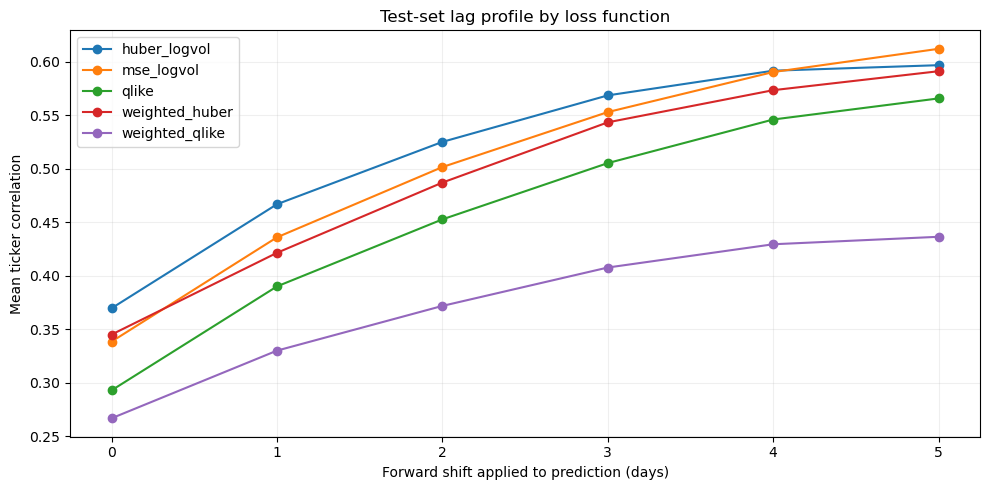

In [6]:
lag_plot_df = []
for name, lag_curve in test_lag_curve_map.items():
    curve = lag_curve.copy()
    curve['experiment'] = name
    lag_plot_df.append(curve)
lag_plot_df = pd.concat(lag_plot_df, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
for name, group in lag_plot_df.groupby('experiment'):
    ax.plot(group['lag'], group['corr'], marker='o', label=name)
ax.set_title('Test-set lag profile by loss function')
ax.set_xlabel('Forward shift applied to prediction (days)')
ax.set_ylabel('Mean ticker correlation')
ax.legend(loc='best')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Plot representative stocks

To keep the figure readable, the stock-level plot overlays:

- `mse_logvol` as the current baseline,
- the experiment with the best `test_qlike`,
- the experiment with the lowest `test_lag_days` and strongest lag-adjusted correlation.

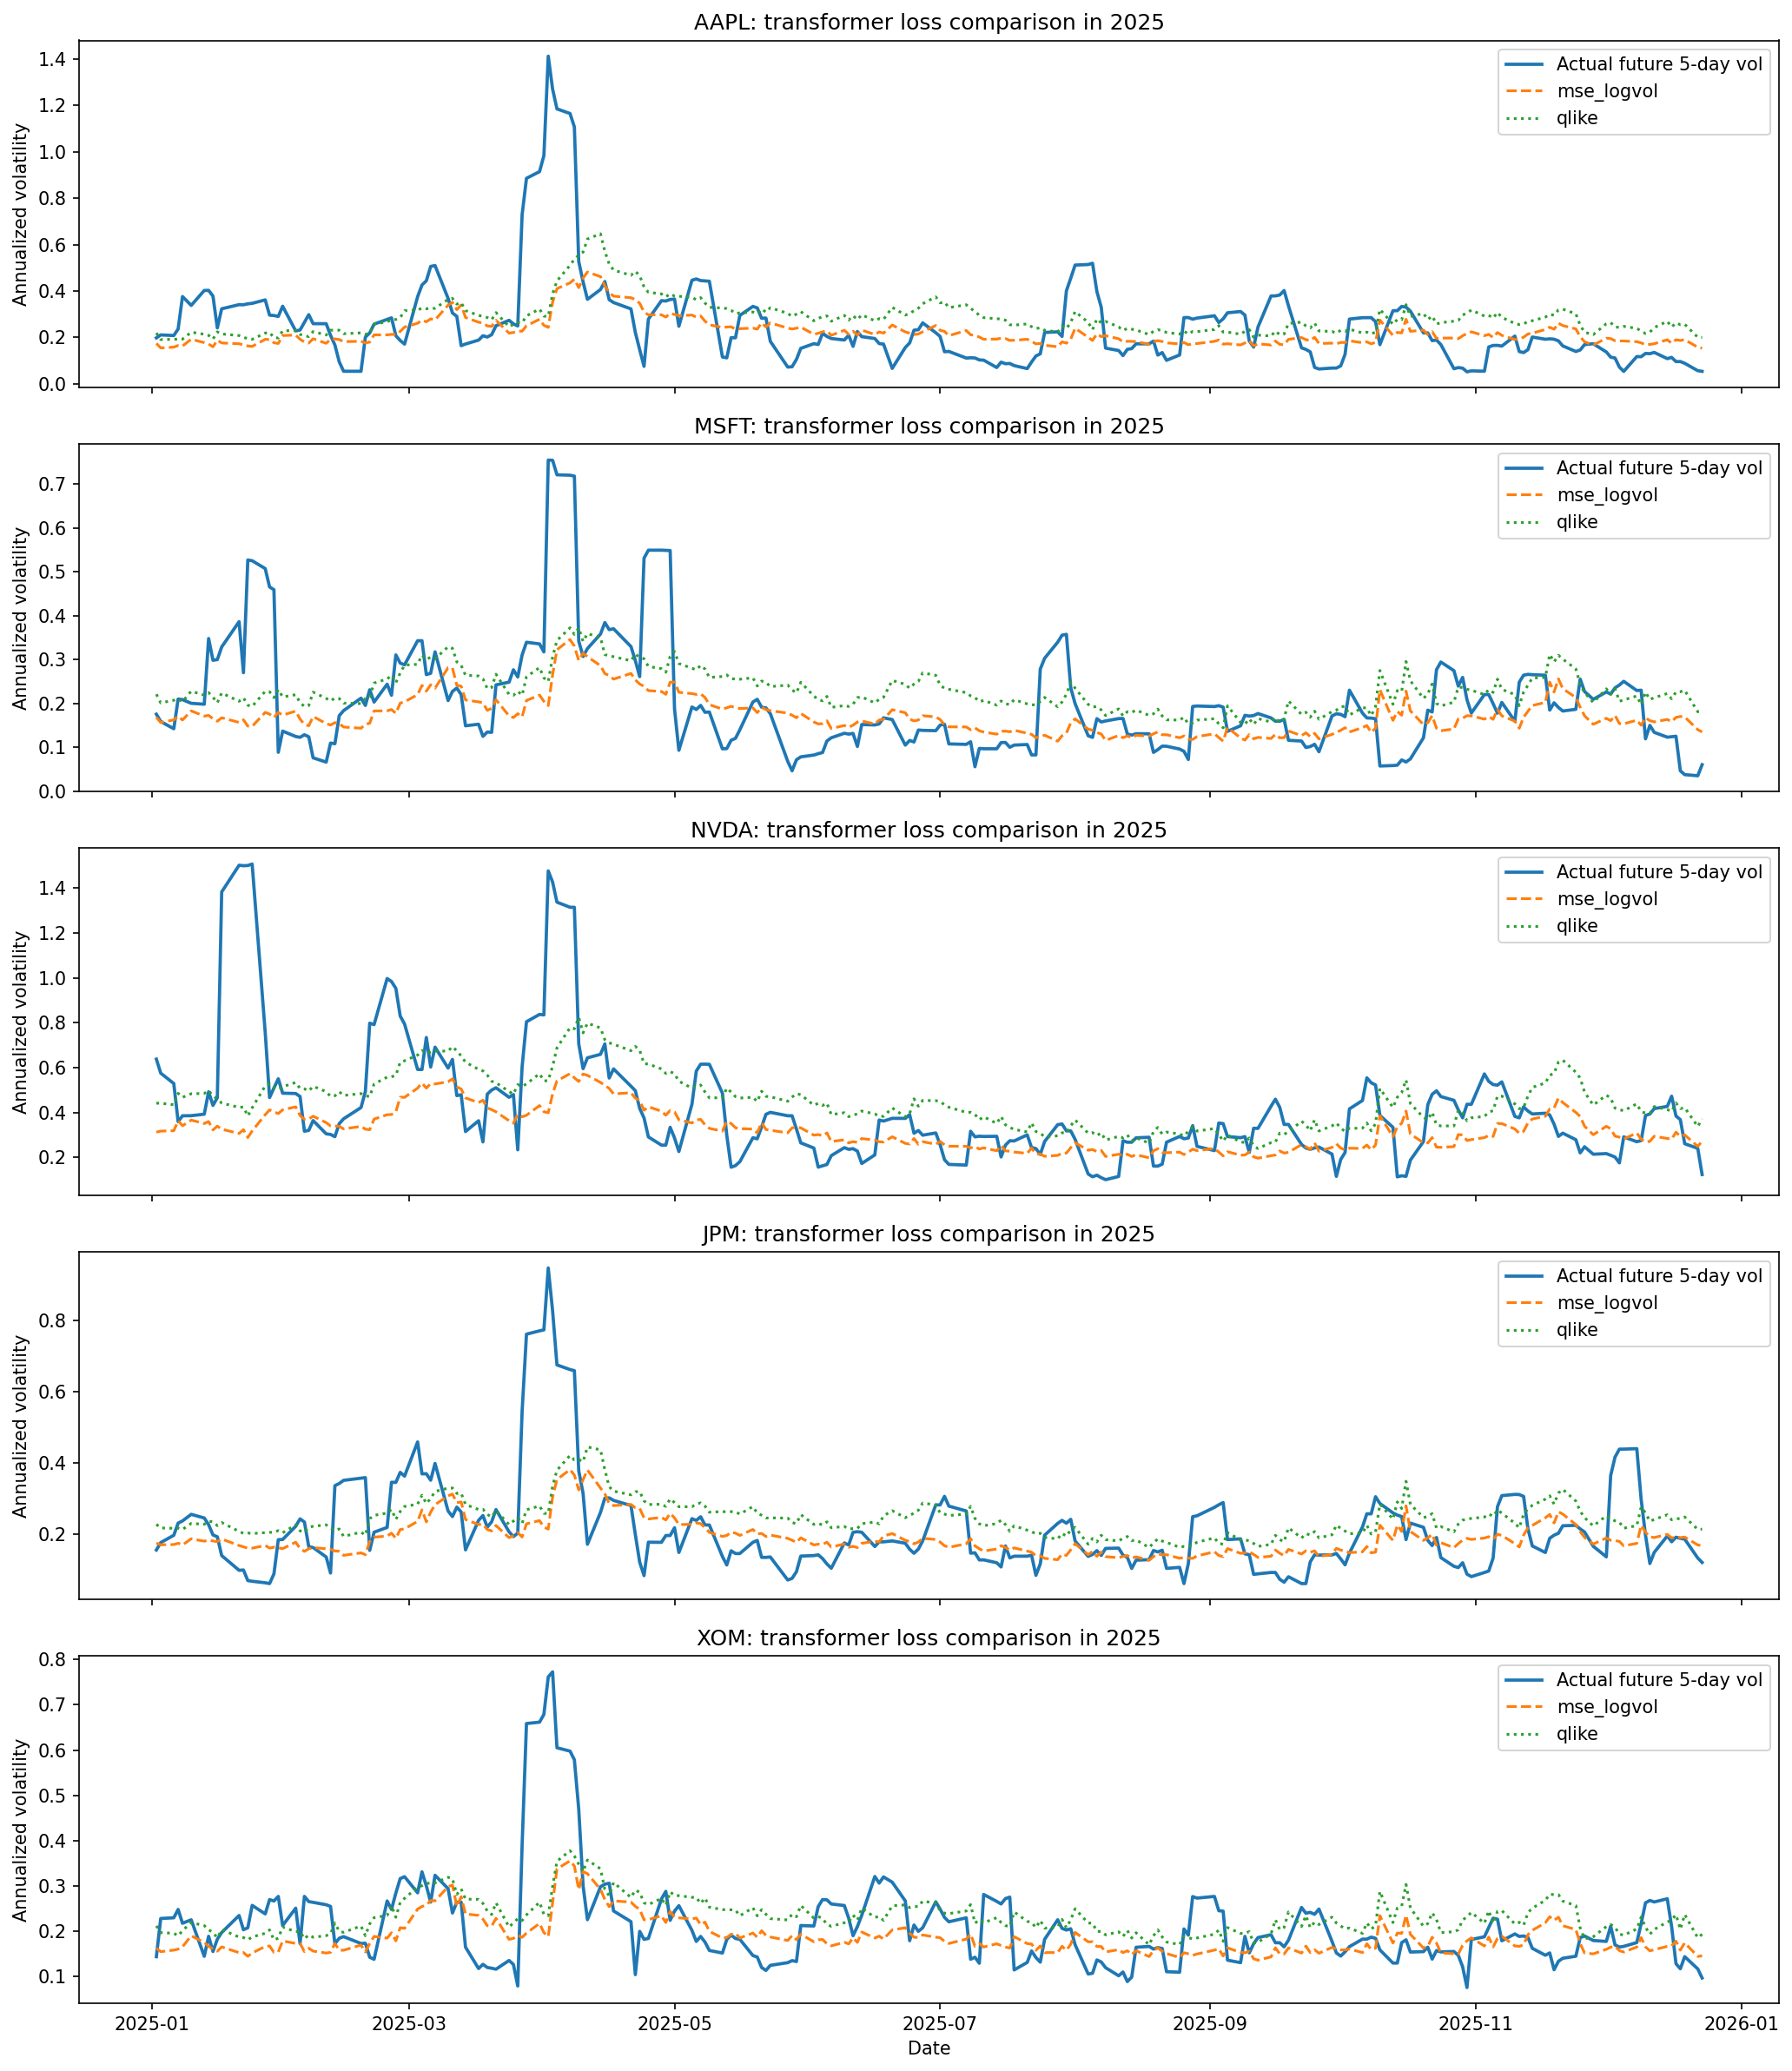

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_loss_functions_5stocks.png')

In [7]:
best_qlike_name = experiment_summary_df.sort_values('test_qlike').iloc[0]['experiment']
best_lag_name = experiment_summary_df.sort_values(['test_lag_days', 'test_lag_best_corr'], ascending=[True, False]).iloc[0]['experiment']
plot_experiments = []
for name in ['mse_logvol', best_qlike_name, best_lag_name]:
    if name not in plot_experiments:
        plot_experiments.append(name)

plot_df = test_prediction_map[plot_experiments[0]].rename(columns={'prediction': plot_experiments[0]})
for name in plot_experiments[1:]:
    plot_df = plot_df.merge(
        test_prediction_map[name][['Date', 'Ticker', 'prediction']].rename(columns={'prediction': name}),
        on=['Date', 'Ticker'],
        how='left',
    )

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)
linestyles = ['--', ':', '-.']

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    for linestyle, name in zip(linestyles, plot_experiments):
        ax.plot(stock_plot_df['Date'], stock_plot_df[name], label=name, linestyle=linestyle, linewidth=1.5)
    ax.set_title(f'{ticker}: transformer loss comparison in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

loss_plot_path = FIGURE_DIR / 'transformer_loss_functions_5stocks.png'
plt.savefig(loss_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(loss_plot_path)))

loss_plot_path

## How to read the result

A good next-step loss should ideally do **at least one** of these things:

- lower `test_qlike` without hurting the other metrics too much,
- keep `RMSE` and `MAE` competitive while increasing `corr`,
- reduce `lag_days` toward zero.

In other words, the question is not just whether one loss wins on one number, but whether it gives a better overall volatility forecast profile.